# 타이타닉 EDA 리포트

**작성자** :   
**작성일** : 

---

> 이 노트북은 **EDA 리포트** 형식입니다.  
> 코드를 돌리는 것으로 끝내지 말고, 각 섹션의 마크다운 셀에 **해석을 남기세요.**

### 목차

| 섹션 | 내용 |
|---|---|
| 0 | 준비 — 라이브러리와 데이터 |
| 1 | 분석 목적 및 질문 |
| 2 | 데이터 개요 |
| 3 | 데이터 품질 점검 — 결측치 |
| 4 | 상관관계 분석 |
| 5 | 그룹별 생존율 비교 |
| 6 | 요금 분포와 치우침 |
| 7 | 텍스트에서 파생변수 만들기 |
| 8 | 통계 검정 |
| 9 | 발견 사항 · 다음 단계 · 한계 |

## 0. 준비

In [4]:
%pip install matplotlib seaborn

   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ------------------------ --------------- 5.8/9.3 MB 29.3 MB/s eta 0:00:01
   ---------------------------------------- 9.3/9.3 MB 32.3 MB/s  0:00:00
   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   ---------------------------------------- 2.5/2.5 MB 35.8 MB/s  0:00:00

   ----- ---------------------------------- 1/7 [kiwisolver]
   ----------- ---------------------------- 2/7 [fonttools]
   ----------- ---------------------------- 2/7 [fonttools]
   ----------- ---------------------------- 2/7 [fonttools]
   ----------- ---------------------------- 2/7 [fonttools]
   ----------- ---------------------------- 2/7 [fonttools]
   ----------- ---------------------------- 2/7 [fonttools]
   ----------- ---------------------------- 2/7 [fonttools]
   ----------- ---------------------------- 2/7 [fonttools]
   ----------- ---------------------------- 2/7 [fonttools]
   ----------- --------------------

In [56]:
import numpy as np
import pandas as pd

In [55]:
from matplotlib import pyplot as plt
import seaborn as sns

In [6]:
# 그래프 폰트 설정
import matplotlib
from matplotlib import font_manager

for _f in ['Malgun Gothic', 'AppleGothic', 'NanumGothic',
           'Noto Sans CJK KR', 'Noto Sans CJK JP']:
    if _f in {f.name for f in font_manager.fontManager.ttflist}:
        plt.rcParams['font.family'] = _f
        break
plt.rcParams['axes.unicode_minus'] = False   # 음수 부호 깨짐 방지
print('font:', plt.rcParams['font.family'])

font: ['Malgun Gothic']


### 데이터 불러오기

In [93]:
FILE_PATH = 'titanic.csv'
df = pd.read_csv(FILE_PATH)

df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


---

## 1. 분석 목적

**이 분석으로 무엇을 알고 싶은지 한 문장으로 적으세요.**

**분석 목적** : 타이타닉 탑승 승객들의 생존을 결정지었던 요인을 찾고, 이후 모델에 사용할 변수를 선별하기 위함

---

## 2. 데이터 개요

크기 · 타입 · 기초 통계량을 확인합니다.

In [8]:
df.shape

(891, 12)

In [9]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.info()
# float일 경우 결측치가 있다고 생각할 수 있음

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [ ]:
df.describe()
# 생존율: bool로 생존 여부 기록, 평균치로 생존율 확인
# 

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [12]:
df.describe(include='all')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [13]:
df.describe(include='O')

C:\Users\kevin\AppData\Local\Temp\ipykernel_33948\2537740217.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='O')


,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,1,577,7,4,644


**여기서 확인 가능한 것**

- 행/열 수 : 
- 결측이 있는 컬럼 : 
- 평균과 중앙값이 크게 다른 컬럼 : 
- 타깃(`Survived`) 의 비율 : 

### 변수 사전

각 컬럼의 의미와 유형을 정리하세요. **이 표가 이후 모든 분석 선택의 기준**이 됩니다.

| 컬럼 | 의미 | 유형 | 결측 |
|---|---|---|---|
| PassengerId | 승객 번호 | 식별자 | 0 |
| Survived | 생존 여부 0/1 — **타깃** | 범주형-명목(이진) | 0 |
| Pclass | 객실 등급 1~3 | 범주형-순서 | 0 |
| Name | 이름 (호칭 포함) | 텍스트 | 0 |
| Sex | 성별 | 범주형-명목(이진) | 0 |
| Age | 나이 | 수치형-연속 | 177 |
| SibSp | 동승 형제·배우자 수 | 수치형-이산 | 0 |
| Parch | 동승 부모·자녀 수 | 수치형-이산 | 0 |
| Ticket | 티켓 번호 | 식별자 | 0 |
| Fare | **티켓 단위** 요금 합계 | 수치형-연속 | 0 |
| Cabin | 객실 번호 | 텍스트 | 687 |
| Embarked | 승선 항구 S/C/Q | 범주형-명목 | 2 |

> 유형 후보 : 수치형-연속 / 수치형-이산 / 범주형-명목 / 범주형-순서 / 식별자 / 텍스트

---

## 3. 데이터 품질 점검 — 결측치

결측은 **얼마나** 비었는지보다 **왜** 비었는지가 중요합니다.
처리 방법은 그 판단에서 갈립니다.

In [94]:
# TODO 결측 개수와 비율을 구해 보세요.  isna().sum() / isna().mean() 활용
na=pd.DataFrame({
    '결측 수':df.isna().sum(),
    '결측률(%)':(df.isna().mean()*100).round(1)
})
na[na['결측 수']>0]

,결측 수,결측률(%)
Age,177,19.9
Cabin,687,77.1
Embarked,2,0.2


In [95]:
# TODO Cabin 결측률을 객실등급(Pclass)별로 나눠 보세요.
#       결측이 무작위인지 아닌지가 여기서 드러납니다.
df.groupby('Pclass')['Cabin'].apply(lambda x:x.isna().mean()*100).round(2)

Pclass
1    18.52
2    91.30
3    97.56
Name: Cabin, dtype: float64

**처리 계획**

| 컬럼 | 결측 | 처리 방법 | 근거 |
|---|---|---|---|
| Age | 177 (19.9%) | Pclass×Sex 그룹 중앙값으로 대체 | 결측이 등급으로 설명됨. 전체 평균 대체는 같은 값을 한 점에 몰아넣어 표준편차를 약 10% 줄인다 (분산 과소추정) |
| Cabin | 687 (77.1%) | 원본 열은 제외하되 **`HasCabin` 이진 변수로 전환** | 결측이 3등석에 집중 — 기록 여부가 등급·생존을 설명하는 정보(기록과 추적 자체가 잘 안 돼서 생존자 위주로만 기록되었다는 뜻) |
| Embarked | 2 (0.2%) | 최빈값 `S` 로 대체 | 2건뿐이라 영향이 미미하고 S가 전체의 약 72%를 차지 |

In [96]:
# TODO 위 계획대로 결측을 처리해 보세요.
print('처리 전 std:', round(df['Age'].std(), 2))
a=df['Age'].fillna(df['Age'].mean())
print('(평균값)처리 후 std:', round(a.std(), 2))

# df['Age'] = 'Pclass Sex 그룹 중앙값'
b = df['Age'].fillna(df.groupby(['Pclass','Sex'])['Age'].transform('median'))

# df['HasCabin'] = 'Cabin 이진 변수'
df['HasCabin']=df['Cabin'].isna().astype(int)
# df['Embarked'] = '최빈값 대체'
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0])

처리 전 std: 14.53
(평균값)처리 후 std: 13.0


In [97]:
df.describe(percentiles=[.01,.05,.95,.99])
df.describe(include='all')
df['Embarked'].value_counts(normalize=True)
pd.crosstab(df['Pclass'],df['Survived'], normalize='index')
df.groupby(['Pclass','Sex'])['Survived'].mean()

Pclass  Sex   
1       female    0.968085
        male      0.368852
2       female    0.921053
        male      0.157407
3       female    0.500000
        male      0.135447
Name: Survived, dtype: float64

---

## 4. 요금 분포와 치우침

요금의 분포를 시각화해보세요.

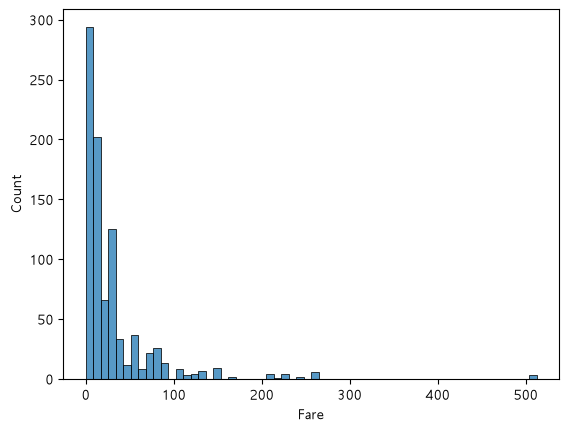

In [61]:
# TODO Fare 의 히스토그램을 그려 보세요.
g=sns.histplot(df,x='Fare')

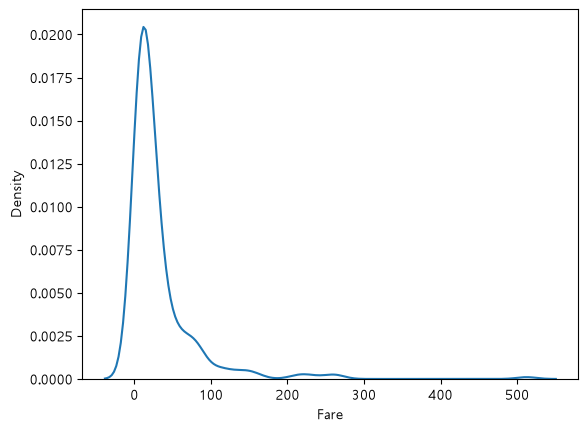

In [60]:
# 밀도 곡선
g = sns.kdeplot(df["Fare"])

In [53]:
# TODO Fare 의 왜도(skewness)를 구해 보세요.
df.skew(numeric_only=True) # numeric_only 옵션이 있어야 오류 없음

PassengerId    0.000000
Survived       0.478523
Pclass        -0.630548
Age            0.389108
SibSp          3.695352
Parch          2.749117
Fare           4.787317
dtype: float64

skewness는 -2 이하, 2 이상이 기준

치우침(Skewness)가 가장 심한 feature가 무엇인지 찾아보세요.

In [98]:
# TODO 전체 수치형 컬럼의 왜도를 구해 정렬하고, 표와 막대그래프로 만들어 보세요. 
# 순서
# 1. skew(numeric_only=True), 내림차순 정렬
# 2. 데이터프레임 생성 (skew, feature)
# 3. display(), sns.catplot()
skew=df.skew(numeric_only=True).sort_values(ascending=False).drop(['PassengerId'])
skew

skew_df=pd.DataFrame(skew,columns=['skew'])
display(skew_df)

g=sns.catplot(skew_df,x='Feature',y='skew',kind='bar')

,skew
Fare,4.787317
SibSp,3.695352
Parch,2.749117
Survived,0.478523
Age,0.389108
Pclass,-0.630548
HasCabin,-1.292367


ValueError: Could not interpret value `Feature` for `x`. An entry with this name does not appear in `data`.

첨도(Kurtosis)가 가장 심한 feature가 무엇인지 찾아보세요.

In [ ]:
# TODO 첨도를 구해 정렬해 보세요.


- **왜도(skew)** — 치우친 정도. `Fare` 가 압도적으로 큽니다 (약 4.8)  
  오른쪽 꼬리가 길다는 뜻이고, 이래서 평균 > 중앙값이 됩니다
- **첨도(kurtosis)** — 뾰족한 정도, 꼬리의 두께. 극단값이 얼마나 자주 나타나는가

**처리 방향**

- 왜도가 크면 **로그 변환**을 검토합니다. `np.log1p(Fare)` 를 쓰면 왜도가 크게 줄어듭니다.

**왜 이렇게 긴 꼬리가 생겼을까**

In [100]:
# TODO 같은 Ticket을 공유한 인원수를 세는 GroupSize 를 만들어 보세요.
df['GroupSize']=df.groupby('Ticket')['Ticket'].transform('size')

1인당 요금으로 바꾸면 왜도가 줄어드는가

In [101]:
# TODO 1인당 요금 FarePerPerson 을 만들어 보세요.
df['FarePerPerson']=df['Fare']/df['GroupSize']

In [102]:
# TODO Fare 와 FarePerPerson 의 왜도·첨도를 나란히 비교해 보세요.
display(df[['Fare','FarePerPerson']].skew())
display(df[['Fare','FarePerPerson']].kurt())

Fare             4.787317
FarePerPerson    4.380561
dtype: float64

Fare             33.398141
FarePerPerson    28.578439
dtype: float64

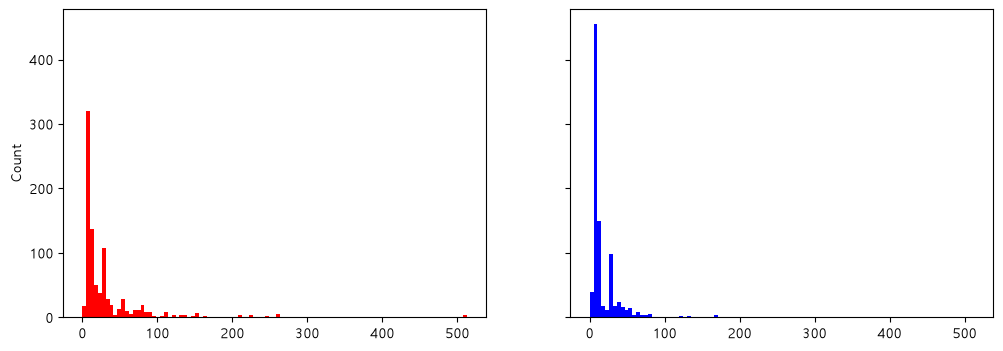

In [103]:
# TODO 두 분포를 히스토그램 두 개로 나란히 그려 비교해 보세요.
#      ※ 축 범위를 통일해야 비교가 됩니다 (sharex)
fig,axes=plt.subplots(1,2,figsize=(12,4),sharex=True,sharey=True)
bins=np.linspace(0,df['Fare'].max(),100) # bin 갯수 조절하여 데이터 해석을 달리할 수 있음
axes[0].hist(df['Fare'],bins=bins,color='red')
axes[1].hist(df['FarePerPerson'],bins=bins,color='blue')
axes[0].set_ylabel('Count')

plt.show()

In [ ]:
# TODO 두 feature의 기초 통계를 확인해보세요


---

## 5. 단일 분포 & 그룹간 분포

생존자와 사망자 간의 각 나이 분포도를 히스토그램으로 시각화해보세요.

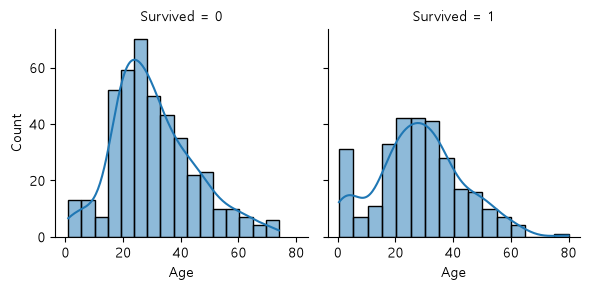

In [80]:
# sns subplot 그리기 (col 기준) (row 기준)
g = sns.FacetGrid(df, col='Survived')
g = g.map(sns.histplot, 'Age', kde=True) # kernel density estimate to smooth the distribution and show on the plot as (one or more) line(s)

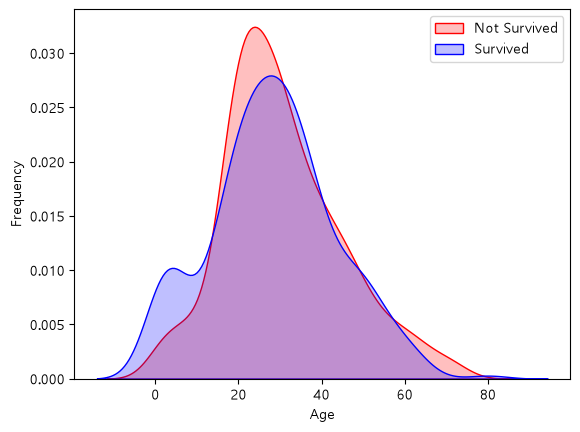

In [ ]:
# kde plot
g = sns.kdeplot(df["Age"][(df["Survived"] == 0) & (df["Age"].notnull())], color="Red", fill= True)
g = sns.kdeplot(df["Age"][(df["Survived"] == 1) & (df["Age"].notnull())], ax=g, color="Blue", fill= True) # ax: 같은 그래프 칸에 겹쳐서 표시
g.set_xlabel("Age")
g.set_ylabel("Frequency")
g = g.legend(["Not Survived", "Survived"])

**나이 분포에서 확인되는 것**

- 

※ 그래프 그릴 때 주의사항: **축 범위를 통일**해야 비교가 가능

**Bar Plot**

['Pclass', 'SibSp', 'Parch'] 각각을 bar plot으로 시각화해보세요.

검은색 bar는 오차막대(error bar) 이며 신뢰구간(confidence interval) 95%

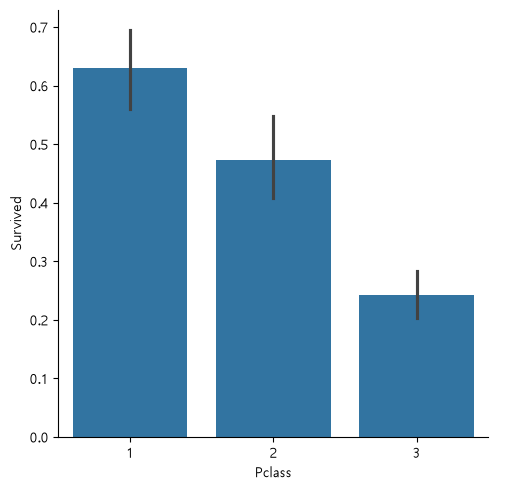

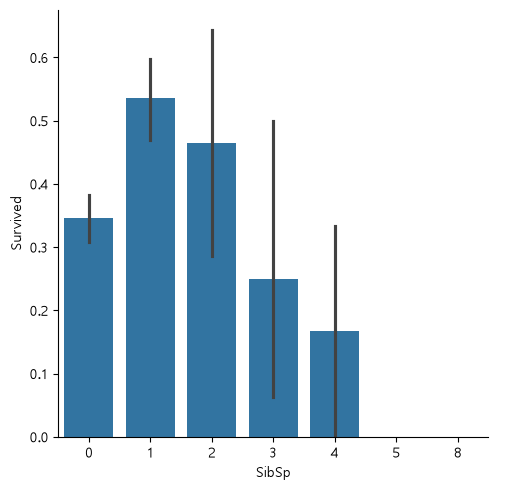

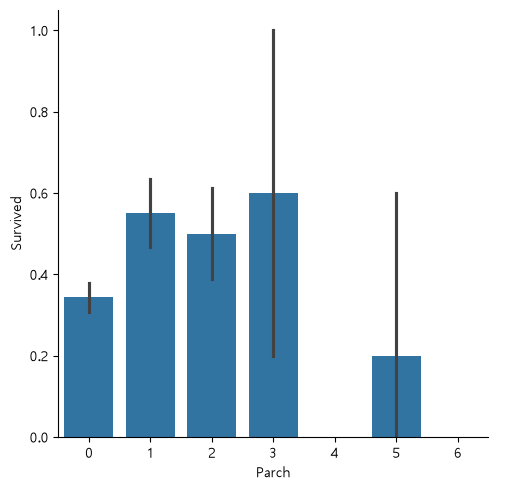

In [83]:
# TODO Pclass · SibSp · Parch 각각 생존율을 막대로 그려 보세요. sns.catplot(), kind=bar 활용
g=sns.catplot(df,x='Pclass',y='Survived',kind='bar')
g=sns.catplot(df,x='SibSp',y='Survived',kind='bar')
g=sns.catplot(df,x='Parch',y='Survived',kind='bar')

plt.show()

성별에 따른 생존율을 비교해보세요.  
남자 : 생존율  
여자 : 생존율  

In [ ]:
# TODO 성별 생존율을 비교해보세요.

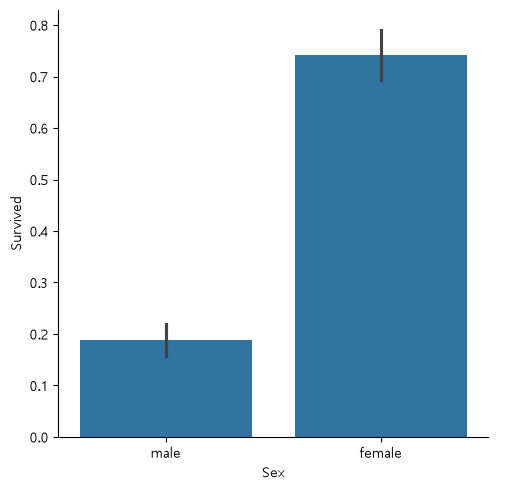

In [87]:
g = sns.catplot(x='Sex', y='Survived', data=df, kind='bar')

객실등급에 따른 생존율을 비교해보세요.  
1등급 : 생존율  
2등급 : 생존율  
3등급 : 생존율  

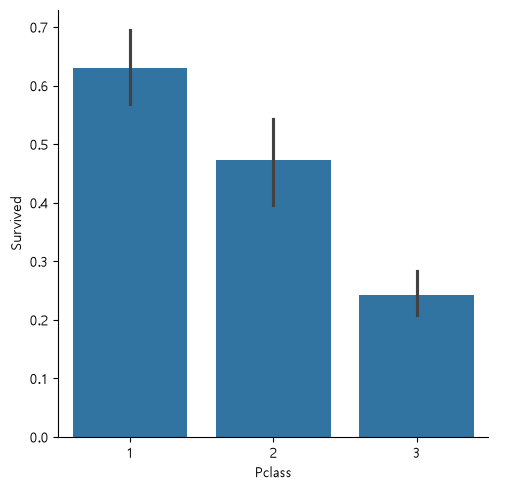

In [85]:
g = sns.catplot(x='Pclass', y='Survived', data=df, kind='bar')

하나의 그래프에 객실등급과 성별에 대한 생존율을 함께 시각화해보세요.

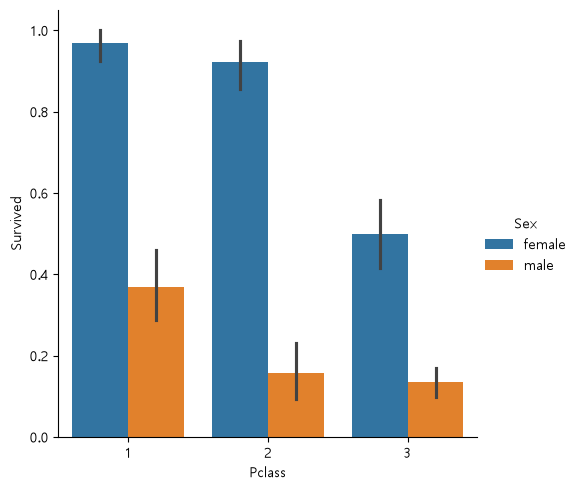

In [89]:
# TODO hue 파라미터로 등급 × 성별을 한 그래프에 그려 보세요.
g=sns.catplot(df,x='Pclass',y='Survived',hue='Sex',kind='bar')

**무엇을 알 수 있는가?**

1. 성별 격차가 전체 등급에서 보인다.
2. 1등석 남성보다 3등석 여성의 생존율이 높다.

※결론: 성별과 등급은 생존 여부에 독립적으로 작용한다.

성별에 따른 나이의 분포를 분석해보세요.  
객실등급에 따른 나이의 분포를 분석해보세요.

In [ ]:
df[['Age', 'Sex']].groupby(['Sex']).mean()

In [ ]:
df[['Age', 'Pclass']].groupby(['Pclass']).mean()

c:\Users\kevin\anaconda3\envs\campus\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 85.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\kevin\anaconda3\envs\campus\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 72.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\kevin\anaconda3\envs\campus\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 92.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\kevin\anaconda3\envs\campus\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 85.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


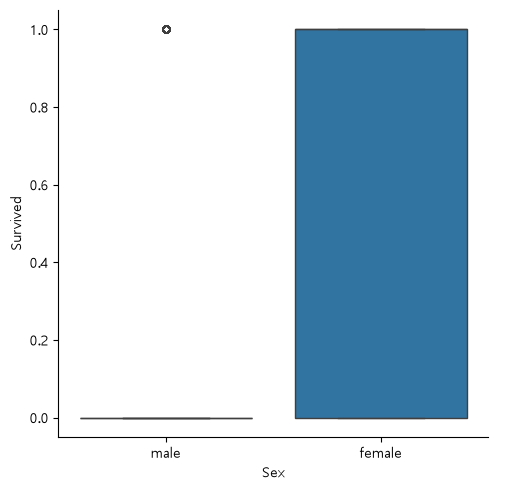

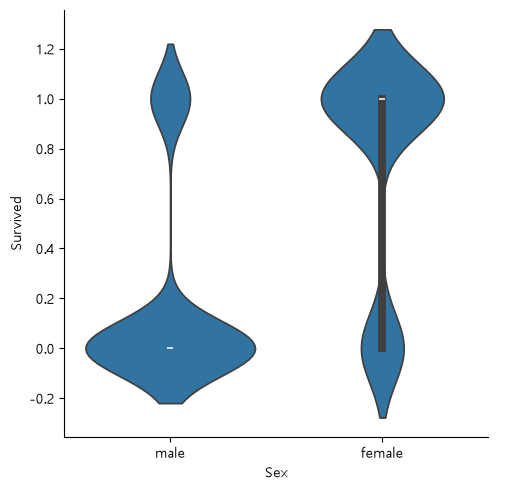

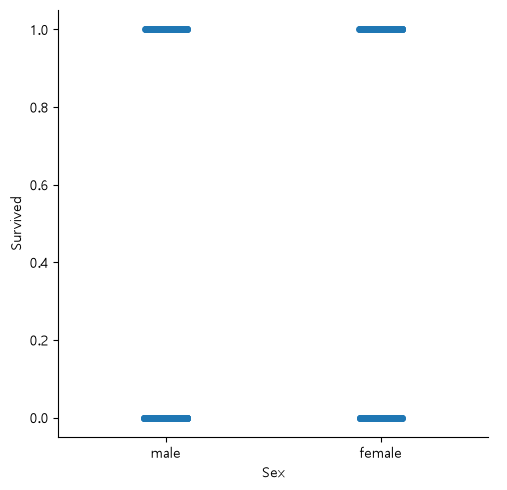

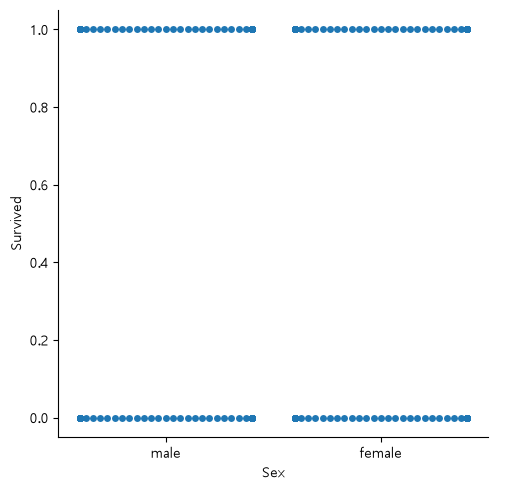

In [ ]:
# TODO box · violin · strip · swarm 네 가지로 그려 비교해 보세요. sns.catplot()에 kind만 변경. Sex, Pclass 2개씩 적용
g=sns.catplot(df,x='Sex',y='Survived',kind='box')
g=sns.catplot(df,x='Sex',y='Survived',kind='violin')
g=sns.catplot(df,x='Sex',y='Survived',kind='strip')
g=sns.catplot(df,x='Sex',y='Survived',kind='swarm')

**네 가지 그래프의 차이**

| 종류 | 보여주는 것 | 한계 |
|---|---|---|
| `box` | 5수 요약 + 이상치 | 봉우리가 두 개인 분포를 놓친다 |
| `violin` | 분포의 **형태**까지 | 표본이 적으면 과장된다 |
| `strip` | 개별 점 전부 | 점이 겹친다 |
| `swarm` | 겹치지 않게 배치한 개별 점 | 데이터가 많으면 느리고 경고가 뜬다 |

**등급이 높을수록 평균 나이가 많습니다.** 경제력과 연령의 관계로 해석할 수 있습니다.  
이 사실은 `Age` 결측을 **등급별로** 채운 근거와 연결됩니다.

항구에 따른 생존율을 시각화해보세요.

In [ ]:
# TODO 승선 항구별 생존율을 그려 보세요.


항구에 따라 생존율의 차이가 있습니다.  
왜일까?  
항구에 따라 탑승하는 객실등급 수준의 차이가 있는건 아닐까?

In [ ]:
# TODO 항구별 평균 객실등급을 확인해 보세요.


In [ ]:
count_em_pc = df[['Pclass', 'Embarked', 'PassengerId']].groupby(['Embarked', 'Pclass']).count()
count_em_pc

  count plot을 이용해서 표현해보자.

In [ ]:
g = sns.catplot(x="Pclass", col="Embarked",  data=df,
                   kind="count", palette="muted")

항구와 객실등급에 따른 생존율

In [ ]:
g = sns.catplot(x='Embarked', y='Survived', data=df, kind='bar',
                   aspect=1)

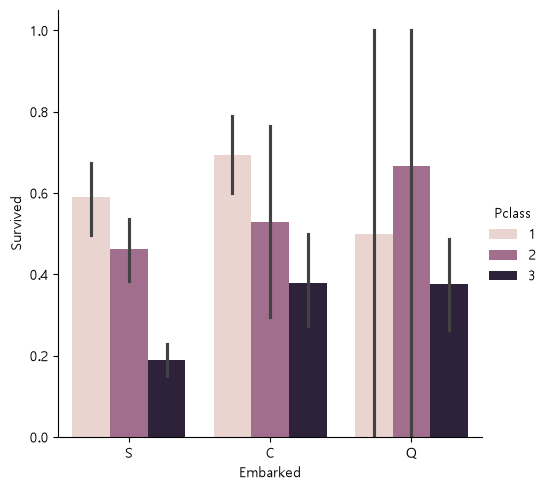

In [ ]:
# TODO 항구 × 등급으로 나눠 생존율을 그려 보세요.
g=sns.catplot(df,x='Embarked',y='Survived',hue='Pclass',kind='bar',aspect=1)
# Q는 표본수가 너무 적어 제외하는 것이 적절

**교란변수(confounder)를 잡아낸 순간입니다.**

C 항구의 생존율이 높았던 것은 **항구 자체의 효과가 아니라**,  
C에서 1등석 승객이 많이 탔기 때문입니다.

등급으로 나눠 보면 항구 간 차이가 크게 줄어듭니다.


> **합쳐서 본 값과 나눠서 본 값이 다르면 교란변수가 숨어 있습니다.**  
> 전체 수치를 보고할 때는 주요 그룹으로 분해해도 결론이 유지되는지 확인해야 합니다.

---

## 6. 상관관계 분석

생존율과 객실등급 간의 상관관계를 분석해보세요.

In [107]:
col = list(df)
col.pop(0)

'PassengerId'

In [108]:
col.insert(0, col.pop())

In [109]:
df[col[:3]]

,FarePerPerson,Survived,Pclass
0,7.2500,0,3
1,71.2833,1,1
2,7.9250,1,3
3,26.5500,1,1
4,8.0500,0,3
...,...,...,...
886,13.0000,0,2
887,30.0000,1,1
888,11.7250,0,3
889,30.0000,1,1


In [110]:
df[:5]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,HasCabin,GroupSize,FarePerPerson
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,1,1,7.2500
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,0,1,71.2833
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,1,7.9250
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,0,2,26.5500
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1,1,8.0500


In [ ]:
# TODO Survived 와 Pclass 의 상관계수를 구해 보세요. corr() 메서드 활용


생존율과 다음 컬럼값들 간의 상관관계를 분석해보세요.
['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

상관관계 > Table로 표현해보세요.

In [ ]:
# TODO Survived 열만 뽑아 상관계수 표를 만들어 보세요.
df[['Pclass', 'Age', 'SibSp', 'Parch', 'Fare','Survived']].corr()['Survived']
# Pclass, Fare 그나마 상관성 있음

Pclass     -0.338481
Age        -0.077221
SibSp      -0.035322
Parch       0.081629
Fare        0.257307
Survived    1.000000
Name: Survived, dtype: float64

상관관계 > heatmap으로 표현해보세요.

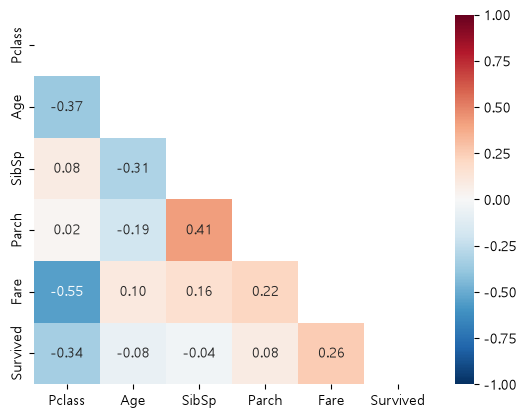

In [ ]:
# TODO 히트맵으로 그려 보세요.  sns.heatmap() 활용, cmap: coolwarm, annot(레이블): 활성화, fmt(포맷): 소숫점 아래 2번째 까지
corr_df=df[['Pclass', 'Age', 'SibSp', 'Parch', 'Fare','Survived']].corr()
g=sns.heatmap(corr_df,vmin=-1,vmax=1,cmap='RdBu_r',annot=True,fmt='.2f',mask=masks)
# 동일 행/열의 1.0 값 마스킹 처리
masks=np.triu(np.ones_like(corr_df,dtype=bool),1)
masks=masks|np.eye(len(masks),dtype=bool) 

---

## 7. 통계 검정

지금까지는 **눈으로 본 차이**입니다. 우연으로 볼 수 있는지 숫자로 확인합니다.

| 묻고 싶은 것 | 변수 유형 | 검정 |
|---|---|---|
| 두 그룹의 평균이 다른가? | 그룹(2) × 수치 | 독립표본 t-검정 |
| 세 그룹 이상의 평균이 다른가? | 그룹(3+) × 수치 | ANOVA |
| 두 범주가 관련 있는가? | 범주 × 범주 | 카이제곱 |

In [119]:
%pip install scipy

   ---------------------------------------- 0.0/36.7 MB ? eta -:--:--
   ------ --------------------------------- 6.3/36.7 MB 32.2 MB/s eta 0:00:01
   ------------------ --------------------- 17.3/36.7 MB 43.7 MB/s eta 0:00:01
   ----------------------------- ---------- 27.0/36.7 MB 45.1 MB/s eta 0:00:01
   ---------------------------------------  36.4/36.7 MB 47.3 MB/s eta 0:00:01
   ---------------------------------------- 36.7/36.7 MB 44.0 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [120]:
from scipy import stats

In [126]:
# TODO 가설 1 — 성별과 생존은 관련이 있다 (범주 × 범주 → 카이제곱) stats.chi2_contingency
female,male=df.groupby('Sex')['Survived'].mean()

tab=pd.crosstab(df['Sex'],df['Survived'])
chi2,p,dof,_=stats.chi2_contingency(tab)
print(f'여성 생존률: {female*100:.2f}%, 남성 생존률: {male*100:.2f}%')
print(f'chi^2: {chi2:.2f}, p-value: {p}')

여성 생존률: 74.20%, 남성 생존률: 18.89%
chi^2: 260.72, p-value: 1.1973570627755645e-58


In [128]:
# TODO 가설 2 — 생존/사망 그룹의 평균 요금이 다르다 (그룹2 × 수치 → t-검정) stats.ttest_ind
alive=df[df['Survived']==1]['Fare']
dead =df[df['Survived']==0]['Fare']

print(f'생존: {alive.mean():.2f}, 사망: {dead.mean():.2f}')

t,p2=stats.ttest_ind(alive,dead,equal_var=False)
print(f't = {t:.2f}, p-value: {p2}')

생존: 48.40, 사망: 22.12
t = 6.84, p-value: 2.6993323503141203e-11


In [ ]:
# TODO 가설 3 — 객실등급별 평균 나이가 다르다 (그룹3+ × 수치 → ANOVA) stats.f_oneway


**해석 문장** — p값만 적지 말고 **차이의 실제 크기**를 함께 쓰세요.

1. 
2. 
3. 

---

## 8. 텍스트에서 파생변수 만들기

In [ ]:
df.head()

In [ ]:
df[['Name', 'Ticket', 'Cabin']].describe()

Name, Ticket, Cabin은 모두 unique값이 많기 때문에, 데이터 자체값으로는 큰의미가 없다. 

데이터를 직접 살펴보고, 유의미한 value를 추출할 수 있을지 고민해야한다.

In [ ]:
df['Name']

In [ ]:
df.Name

전체 이름에서, . 앞에 있는 알파벳묶음열(알파벳으로만 이루어진 문자열)을 찾아내고 싶다면?

In [2]:
# .
# ?
# +
# *
# []
# [^]
# ()

# 이스케이프 시퀀스 \. \? \+ \* \[ \] \^ \( \)

# greedy Q : 최대한 긴 문자열로 찾아낸다. = .+
# lazy Q : 최대한 짧은 문자열로 찾아낸다. = .+?

In [ ]:
import re
text = 'abc.def..ght..xyz.poi'
lq = re.findall(r'\.(.+?)\.', text)
gq = re.findall(r'\.(.+)\.', text)
lq, gq

In [ ]:
# TODO 정규표현식으로 이름에서 호칭(Title)을 추출해 보세요. df.str.extract() 메서드 활용


In [ ]:
# TODO 쉼표 뒤 ~ 마침표 앞을 뽑는 방식으로도 해 보세요.


In [ ]:
# TODO Title 을 Sex · Pclass · Survived 와 각각 교차표로 확인해 보세요. pd.crosstab() 활용


In [ ]:
list(df)

In [ ]:
df['Name'].str.split(',')

이름에서 Mr, Miss 등 성별 혹은 직위를 나타내는 칭호가 있다. 이것은 생존율에 쓸만하지 않을까?

  이녀석만 따로 빼내자.

In [ ]:
[i.split(",")[1] for i in df["Name"]]

In [ ]:
# TODO 문자열 split 만으로도 Title 을 뽑아 보세요 (정규식 없이).


**정규식 vs split — 둘 다 결과는 같다**

- 정규식 : 패턴이 복잡해질수록 유리. 대신 읽기 어렵다
- split : 구분자가 단순하면 더 직관적

실무에서는 **읽기 쉬운 쪽**을 고르면 됩니다.  
다만 `.strip()` 을 빼먹으면 `' Mr'` 처럼 공백이 남아 그룹이 어긋납니다.

Title에 따른 생존율을 비교해보세요.

In [ ]:
# TODO Title 별 생존율을 구해 보세요.


너무 빈도가 적은 Title은 묶어도 되지 않을까?

Mr -> 1
Miss -> 2
Mrs -> 3
Master, Dr -> 4
Rev -> 5
others -> 0

In [ ]:
set([i.split(",")[1].split(".")[0] for i in df["Name"]])

In [ ]:
# TODO 위 매핑대로 Title 을 묶어 TitleCode 를 만들어 보세요.


**묶는 이유**

- 

이와 같이, Cabin도 분석해보세요.

In [ ]:
df['Cabin']

In [ ]:
df['CabinCode'] = df['Cabin'].str[0]

print(df['CabinCode'].value_counts(dropna=False))

In [ ]:
print(pd.crosstab(df['CabinCode'], df['Pclass']).to_string())

g = sns.catplot(x='CabinCode', y='Survived', data=df, kind='bar',
                order=sorted(df['CabinCode'].dropna().unique()))

**갑판 코드는 결국 객실 등급입니다**

A~E 갑판은 대부분 1등석, F~G는 2·3등석입니다.  
즉 `CabinCode` 는 `Pclass` 와 크게 겹칩니다.

> 설명 변수끼리 강하게 겹치면 모델에 둘 다 넣었을 때  
> **어느 쪽이 효과를 낸 것인지 구분할 수 없습니다.**  
> 하나를 빼거나 합치는 것을 검토합니다.

그래서 `Cabin` 에서 실제로 건질 것은 갑판 코드보다  
**3절에서 만든 `HasCabin`(기록 여부)** 쪽입니다.

---

## 9. 발견 사항 · 다음 단계 · 한계

### 발견 사항

번호를 매긴 **사실** 목록으로 정리하세요. 추측과 사실을 구분합니다.

1. 전체 생존률
2. 생존률에 가장 영향 미치는 요인, 그 다음
3. 성별과 객실 등급의 격차
4. 항구별 생존률 차이의 본질
5. Fare
6. 

### 다음 단계 — 모델링에 쓸 변수

**사용할 변수** : `Sex` · `Pclass` · `Age` · `SibSp` · `Parch` · `LogFare` · `HasCabin` · `Embarked` · `TitleCode`

**제외할 변수와 이유**
- `PassengerId` · `Ticket` — 식별자. 정보가 없다
- `Name` — 원본은 제외하되 `TitleCode` 로 정보를 살렸다
- `Cabin` — 결측 77%. `HasCabin` 으로 대체

**만들 파생변수**
- `FamilySize = SibSp + Parch + 1`
- `IsAlone = (FamilySize == 1)`
- `LogFare = np.log1p(Fare)` — 왜도 완화
- `TitleCode` — 8절에서 완성

### 모델링 준비 체크리스트

- [x] 결측 처리 완료 + 근거 기록 (3절)
- [x] 이상치 판단 완료 — `Fare` 는 티켓 합계이므로 **보존** (4절)
- [x] 범주형 변수 인코딩 계획 수립 — `Sex`·`Embarked` 원-핫
- [x] 왜도 큰 변수 변환 여부 결정 — `Fare` 로그 변환
- [x] 타깃 불균형 확인 → 정확도 대신 **F1 · ROC-AUC**
- [x] 서로 강하게 상관된 변수 정리 — `Pclass` ↔ `CabinCode`
- [x] 데이터 누수 가능 변수 제외 — 해당 없음
- [x] 파생변수 후보 정리

In [ ]:
# TODO 파생변수를 실제로 만들어 최종 데이터프레임을 확인해 보세요.


### 한계

이 데이터와 분석의 제약을 적으세요.

- 표본 개수
- Age 결측 개수
- 관측 데이터 한계
- Fare 해석